In [17]:
!pip install ISLP
from ISLP import load_data
import warnings
warnings.filterwarnings("ignore")

###15. This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

###(a) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

In [3]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

boston = load_data("Boston")
df = pd.DataFrame(boston)

In [4]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [16]:
y = df['crim']  # response
X_vars = df.columns.drop('crim')
results = []
for col in X_vars:
    X = sm.add_constant(df[col])
    model = sm.OLS(y, X).fit()
    results.append({
        'Predictor': col,
        'p-value': model.pvalues[1],
        'R-squared': model.rsquared
    })

summary_df = pd.DataFrame(results).sort_values('p-value')
summary_df

,Predictor,p-value,R-squared
7,rad,0.000000,0.391257
8,tax,0.000000,0.339614
10,lstat,0.000000,0.207591
3,nox,0.000000,0.177217
1,indus,0.000000,0.165310
11,medv,0.000000,0.150780
6,dis,0.000000,0.144149
5,age,0.000000,0.124421
9,ptratio,0.000000,0.084068
4,rm,0.000001,0.048069


### summary

1. Most predictors have a statistically significant association with crime rate.

2. rad, tax, lstat, and nox have the strongest linear relationships.

3. chas (用來表示房屋是否鄰近Charles river) is the only non-significant predictor. (p-value>0.05)

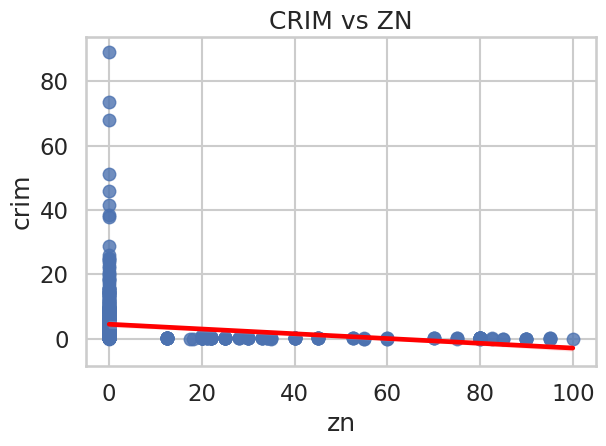

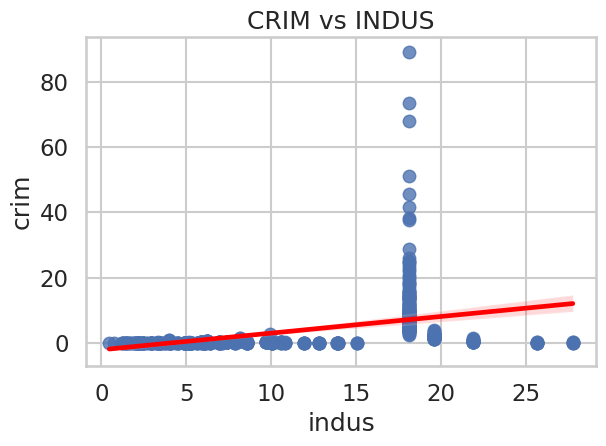

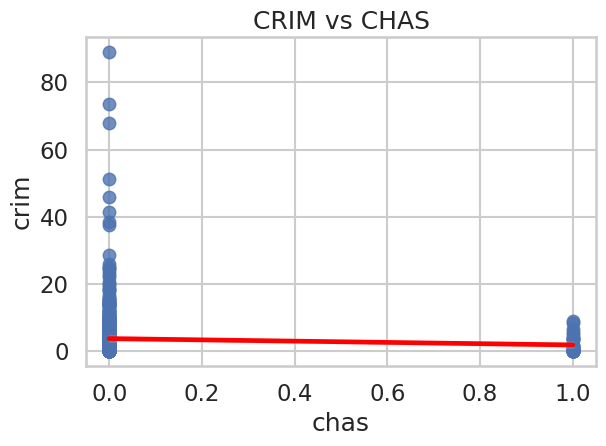

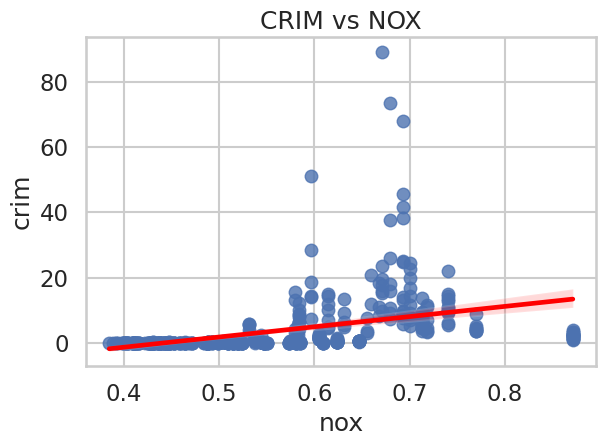

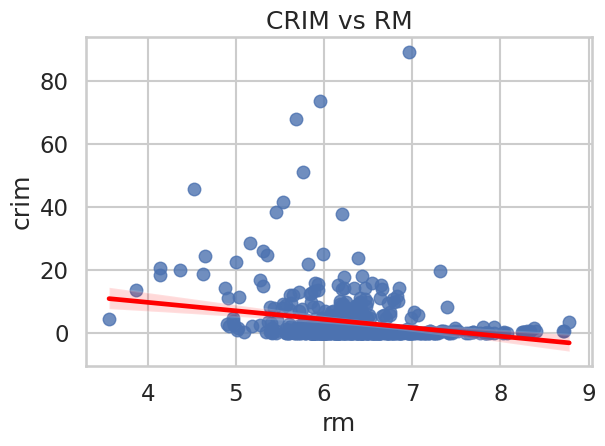

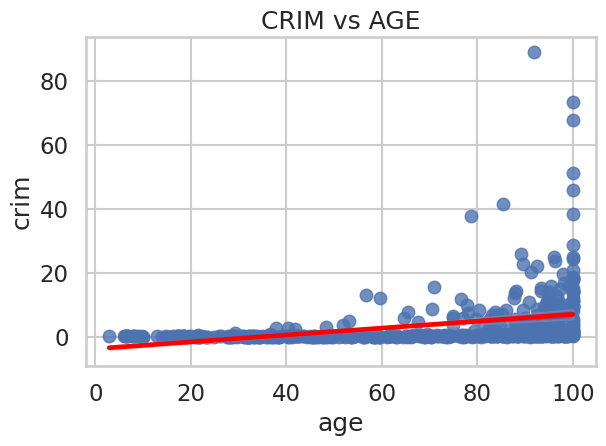

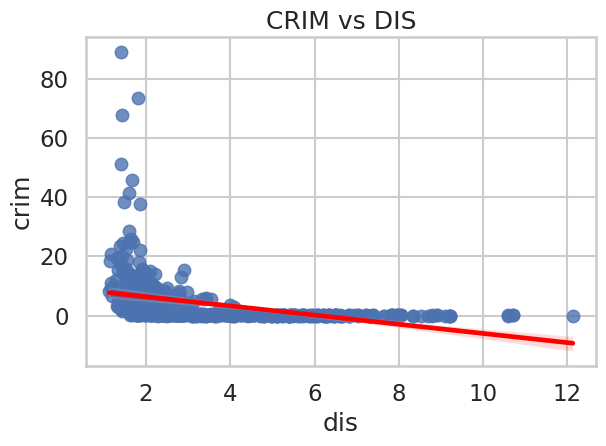

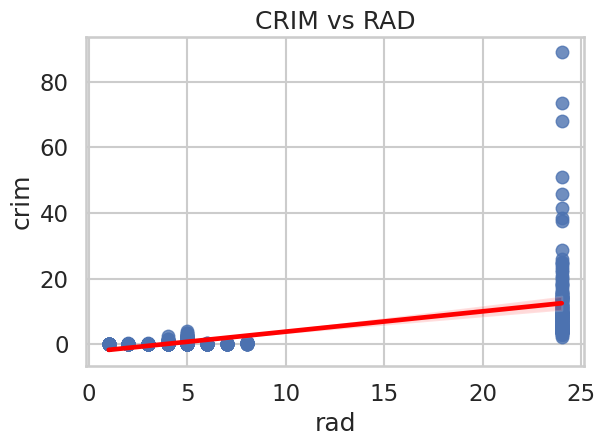

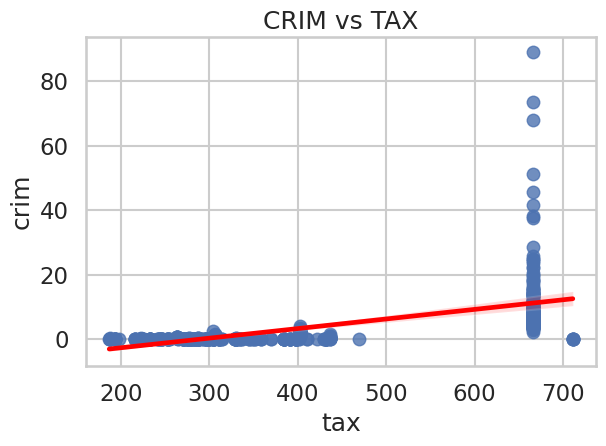

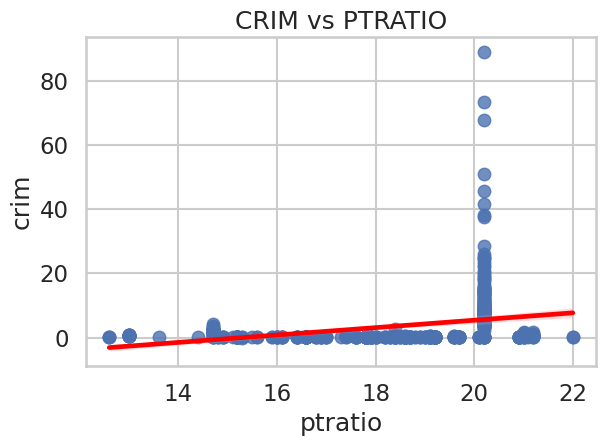

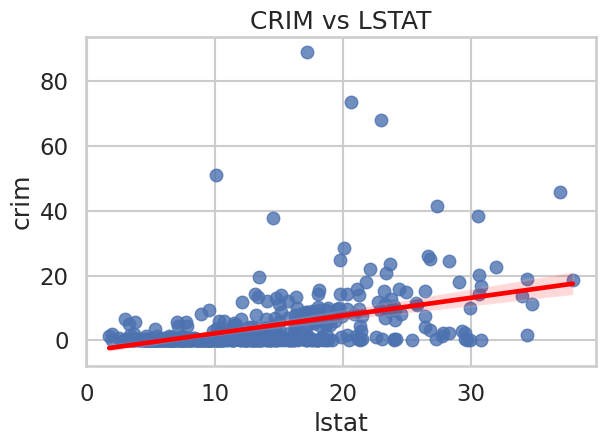

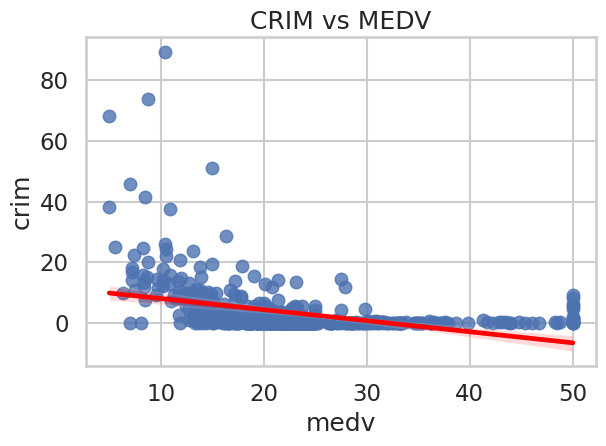

In [6]:
sns.set(style="whitegrid", context="talk")
for col in X_vars:
    sns.regplot(x=col, y='crim', data=df,line_kws={'color': 'red'})
    plt.title(f'CRIM vs {col.upper()}')
    plt.tight_layout()
    plt.show()

### (b) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0 (斜率=0,沒有線性關係)?

In [7]:
y = df['crim']

# Predictors (all except 'crim')
X = df.drop(columns='crim')
X = sm.add_constant(X)  # add intercept

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        13:17:58   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

#### zn, dis, rad, medv has p-value < 0.05, these predictors can reject the null hypothesis.

### (c) How do your results from (a) compare to your results from (b)?

Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

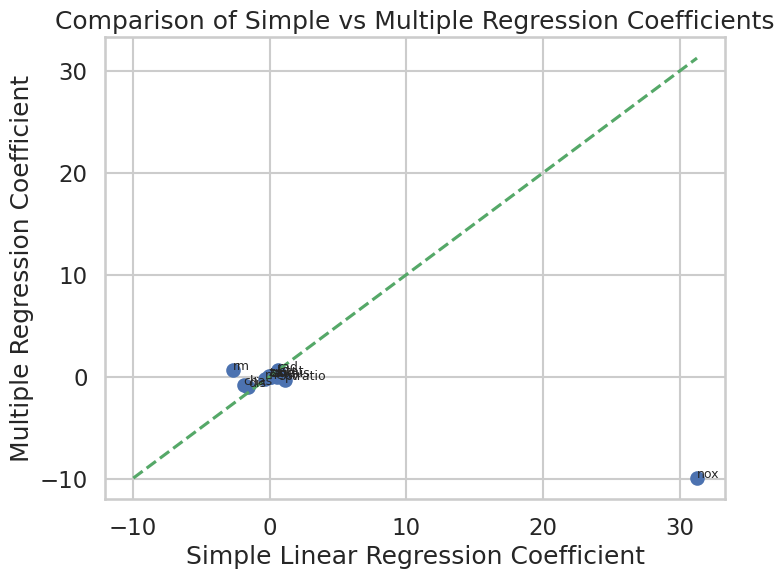

In [15]:
# Extract simple regression coefficients
simple_coefs = []
for col in X_vars:
    X_simple = sm.add_constant(df[col])
    model_simple = sm.OLS(y, X_simple).fit()
    simple_coefs.append(model_simple.params[1])  # slope only
simple_coefs = np.array(simple_coefs)

# multiple regression coefficients
X_multi = sm.add_constant(df[X_vars])
model_multi = sm.OLS(df['crim'], X_multi).fit()
multi_coefs = model_multi.params[X_vars].values  # 用 X_vars 來選，確保順序一致

plt.figure(figsize=(8,6))
plt.scatter(simple_coefs, multi_coefs)

min_val = min(simple_coefs.min(), multi_coefs.min())
max_val = max(simple_coefs.max(), multi_coefs.max())
plt.plot([min_val, max_val], [min_val, max_val], 'g--', label='x = y')


# Add labels for each predictor
for i, col in enumerate(X_vars):
    plt.text(simple_coefs[i], multi_coefs[i], col, fontsize=9)

#plt.axhline(0, color='red', linestyle='--')
#plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Simple Linear Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Comparison of Simple vs Multiple Regression Coefficients')
plt.grid(True)
plt.show()

* Each point = one predictor variable

x-axis: the coefficient from the simple linear regression (one predictor at a time)

y-axis: the coefficient from the multiple linear regression (all predictors together)

* Points on or near the x = y line →
The predictor’s effect is similar in both simple and multiple regressions (little multicollinearity).

* Points far from the line →
The predictor’s coefficient changes a lot when other variables are included —
this often indicates multicollinearity or overlapping information among predictors.

### (d) Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form $Y = b_0 + b_1 X + b_2 X^2 + b_3 X^3 + \varepsilon$.

### This allows the model to capture:

Quadratic patterns (U-shaped or inverted-U curves)

Cubic patterns (more flexible S-shaped curves)

### After fitting this model for each predictor:

* If the p-value of $X^2$ or $X^3$ is significant (typically < 0.05),
→ There is evidence of a nonlinear association between $X$ and $Y$

* If only $X$ is significant, and $X^2$, $X^3$ are not,
→ The relationship is likely linear.


In [14]:
nonlinear_results = []
for col in X_vars:
    X = df[[col]]
    X_poly = np.column_stack([X[col], X[col]**2, X[col]**3])
    X_poly = sm.add_constant(X_poly)

    model = sm.OLS(df['crim'], X_poly).fit()

    # 檢查 b2, b3 的 p-value
    nonlinear_results.append({
        'Predictor': col,
        'p-value X': model.pvalues[1],
        'p-value X^2': model.pvalues[2],
        'p-value X^3': model.pvalues[3]
    })

pd.set_option('display.float_format', '{:.6f}'.format)
nonlinear_df = pd.DataFrame(nonlinear_results).sort_values(by='p-value X^2')
print(nonlinear_df)

   Predictor  p-value X  p-value X^2  p-value X^3
11      medv   0.000000     0.000000     0.000000
3        nox   0.000000     0.000000     0.000000
6        dis   0.000000     0.000000     0.000000
1      indus   0.000053     0.000000     0.000000
9    ptratio   0.003029     0.004120     0.006301
5        age   0.142661     0.047377     0.006680
10     lstat   0.334530     0.064587     0.129891
0         zn   0.002612     0.093750     0.229539
8        tax   0.109708     0.137468     0.243851
2       chas   0.209435     0.209435     0.209435
4         rm   0.211756     0.364109     0.508575
7        rad   0.623418     0.613010     0.482314


There is strong evidence of nonlinear association between crime rate (crim) and variables such as:

* indus (proportion of non-retail business acres)

* nox (nitric oxide concentration)

* dis (distance to employment centers)

* ptratio (pupil–teacher ratio)

* medv (median home value)

These predictors likely affect crime rate in curved or complex ways, not just in a straight-line pattern.

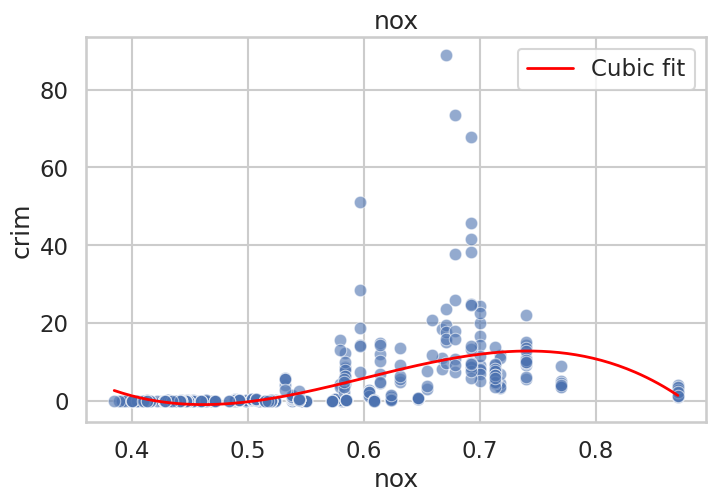

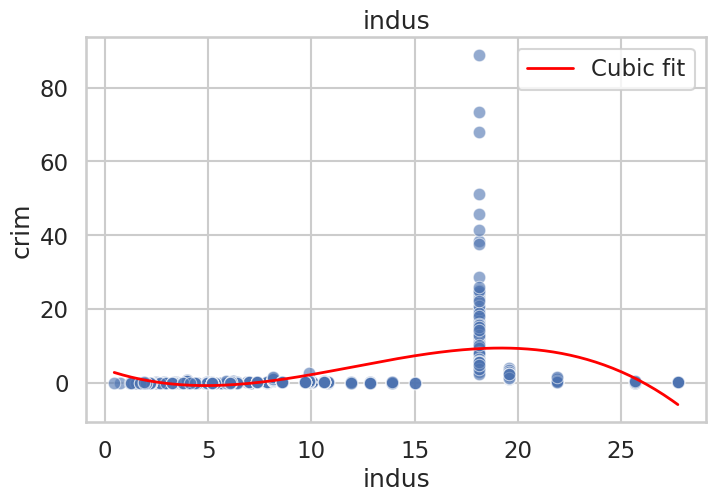

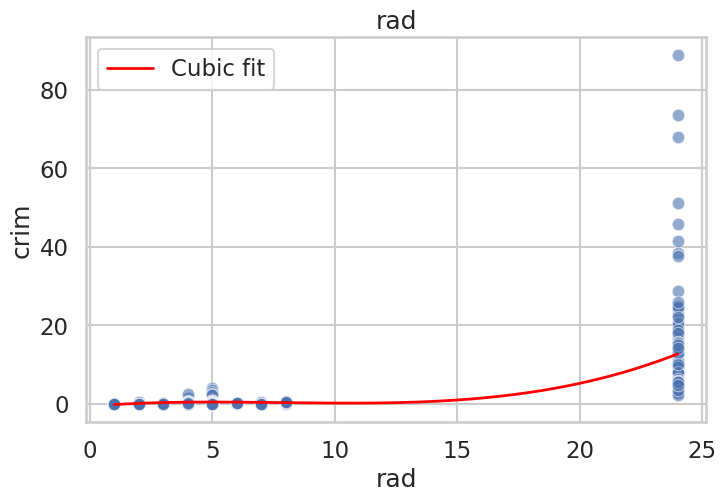

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cubic_fit(predictor_name):
    x = df[predictor_name].astype(float)
    # center to improve numerical stability (optional)
    xc = x - x.mean()

    # design matrix
    X_poly = np.column_stack([xc, xc**2, xc**3])
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly).fit()

    # grid for plotting
    x_grid = np.linspace(x.min(), x.max(), 200)
    xc_grid = x_grid - x.mean()
    Xg = np.column_stack([xc_grid, xc_grid**2, xc_grid**3])
    Xg = sm.add_constant(Xg)
    y_pred = model.predict(Xg)

    plt.figure(figsize=(8,5))
    sns.scatterplot(x=x, y=y, alpha=0.6)
    plt.plot(x_grid, y_pred, color='red', linewidth=2, label='Cubic fit')
    plt.xlabel(predictor_name)
    plt.ylabel('crim')
    plt.title(predictor_name)
    #plt.title(f'Cubic polynomial fit: crim ~ {predictor_name} + {predictor_name}^2 + {predictor_name}^3')
    plt.legend()
    plt.show()

# Example: plot for 'nox'
plot_cubic_fit('nox')
plot_cubic_fit('indus')
plot_cubic_fit('rad')